## PURPOSE

The purpose of this notebook is to test different parameters for the wavelet family to see which gives us the best time frequency decomposition of an example signal.

Here we import the custom classes. The classes include the following:
- Peak and Peak children classes: Classes to create custom waveforms
- Processing step and preprocessor classes: Classes to build the preprocessor pipeline for the simulated data.
- waveletfamily class: Class to create custom wavelet families for the wavelet transform step of the  pipeline.
- Dataset: this is what stores all the simulated data and attributes. It also has functions to generate the JPEG reports for the simulated data (still need to modify the function to do this)

In [1]:
# import libraries
import numpy as np
from fontTools.misc.plistlib import end_data

from custom_classes import *
from matplotlib import pyplot as plt
import pandas as pd

dir()
print(GaussianReboundPeak)
print(type(GaussianReboundPeak))


<class 'custom_classes.GaussianReboundPeak'>
<class 'type'>


Here we will create the peak objects that we will use to create the simulated data. We want to create a peak set for each of the following conditions:
- Normal peak set: this will be the baseline peak set that we will use to create the normal simulated data. It will have a full peak amplitude and a normal shape.
- Abolished peak set: this will be the peak set that we will use to create the abolished simulated data. It will have a very low peak amplitude and a distorted shape.
- Reduced peak set: this will be the peak set that we will use to create the reduced simulated data. It will have a reduced peak amplitude and a slightly distorted shape.
- High noise peak set: this will be the peak set that we will use to create the high noise simulated data. It will have a normal peak amplitude but be very noisy.

In [72]:
settings_for_dataset = {
    "fs": 2000,
    "tmin_ms": -50,
    "tmax_ms": 200,
    "pad_frac": 3.0,
    "crop_after_preprocess": False,
    "latency_jitter_ms": 0,
    "amp_jitter_frac": 0.0,
    "noise_rms_uv": 1.0,
    "noise_type": "pink",
    "n_trials" : 300,
    "generate" : True
}



# set parameters here
p45_delay = 50.0
p45_amp_uv = +1
p45_width_ms = 3.0
p45_rebound_frac = 1.5
p45_rebound_delay_ms = 7
p45_rebound_width_ms = 5.0

p75_delay = 150.0
p75_amp_uv = +1
p75_width_ms = 5.0

# delay for the delayed peaks
peak_delay = 10 # in ms

# multiplied for the reduced peaks
peak_multiplier = 0.5

#norm_peaks = [
#    GaussianReboundPeak("P45", latency_ms=p45_delay, amp_uv=p45_amp_uv, width_ms=p45_width_ms,
#                        rebound_frac=p45_rebound_frac, rebound_delay_ms=p45_rebound_delay_ms, rebound_width_ms=p45_rebound_width_ms),
#    Peak("P75", latency_ms=p75_delay, amp_uv=p75_amp_uv, width_ms=p75_width_ms)
#]

response_freq_1 = 40 # in
response_freq_2 = 60
resp_n_cycles = 3

norm_peaks = [
    WaveletPeak("Wavy1",latency_ms=p45_delay, amp_uv=p45_amp_uv,width_ms=p45_width_ms,freq_hz=response_freq_1, n_cycles=resp_n_cycles, fs_hz=settings_for_dataset["fs"]),

    WaveletPeak("Wavy2",latency_ms=p75_delay, amp_uv=p75_amp_uv,width_ms=p75_width_ms,freq_hz=response_freq_2, n_cycles=resp_n_cycles, fs_hz=settings_for_dataset["fs"]),

]

# normal waveform 30-35 (check)
# conditions - normal latency or delayed or abolished and delayed.

# Dataset simulation
Here we will create the dataset of simulated ssep data. First we will define the parameters for the simulation including number of subjects per condtions, number of trials, the peak sets for each condition. Then we generate a dummy dataset to create the preprocessor pipeline. This same dataset will be used in the next cell to create the corresponding wavelet family for the time frequency decomposition.

In [73]:
# baseline settings for simulation
n_subs_per_condition = 50

# subject specific settings - these will introduce intersubject variability across the different condition. this is done through modifiers in the loop that add latency or multiply the amplitude of each subject response according to a random varable selector in the loop around these ranges
subject_specific_amp_range_uv = {"low": .7, "high": 1.3}   # will modify the amplitude by multiplying it by a modifier
subject_specific_latency_range_ms = {"low": -10, "high": 11}  # will modify the subject latency by adding this modifier- should be plus or minus 10

In [74]:
# storing the settings here
condition_peaks = {
    "normal": norm_peaks,
}

condition_settings = {
    "normal": settings_for_dataset,
}



Generated 300 trials with 2000 time points each.
First trial time range: -425.0 ms to 574.5 ms
First trial signal snippet: [0.81519182 1.59674473 1.18532838 1.04416119 1.21614304 1.90329088
 0.79310117 0.76445904 1.6108332  1.56085456] ...


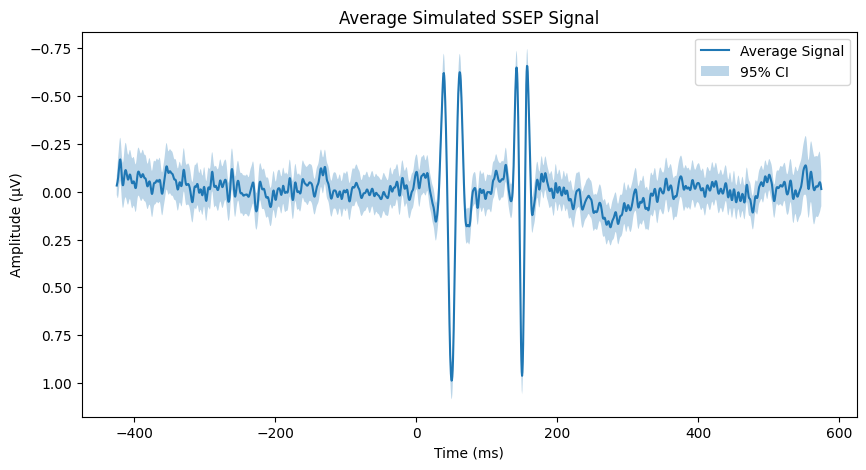

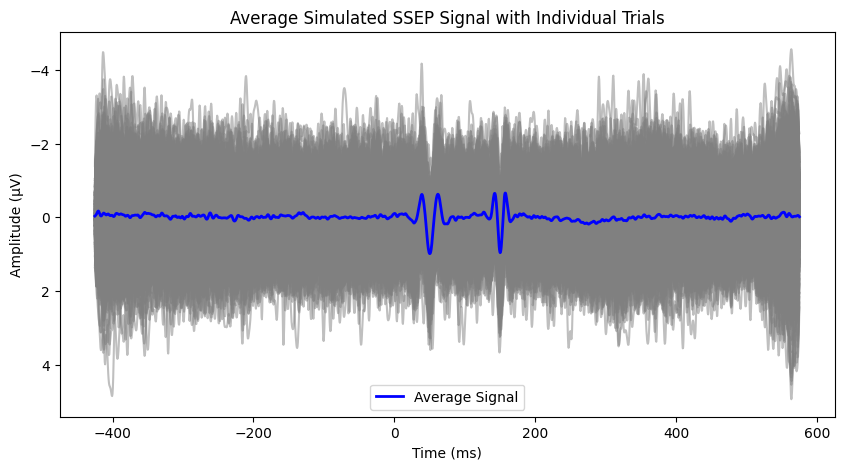

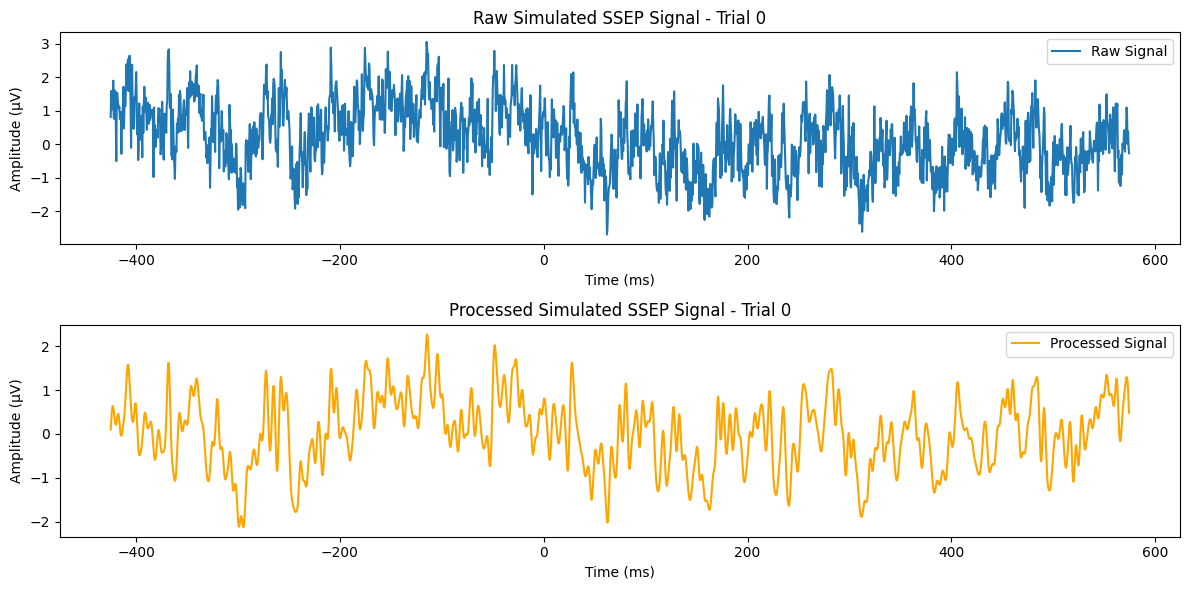

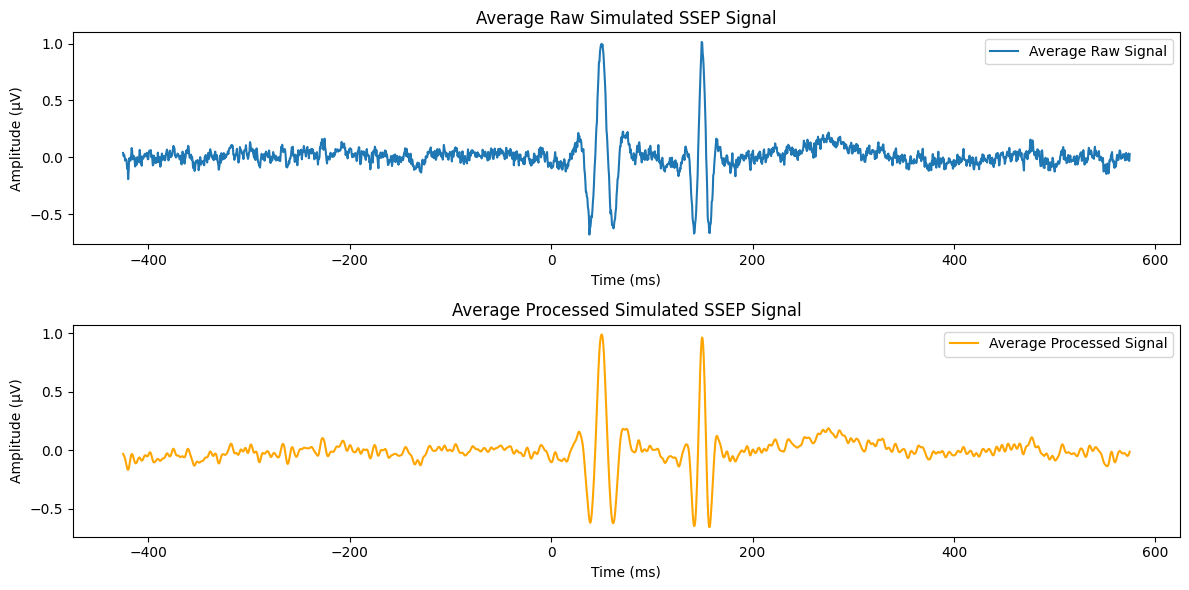

In [75]:
# creating the dummy dataset and actually adding the preprocessor
# dummy dataset to test the dataset class to create the preprocessor pipeline and the wavelet transform settings
dataset = Dataset(peaks=norm_peaks, **settings_for_dataset)

#ataset.generate_trials(n_trials=n_trials)

#print some info about the generated dataset
print(f"Generated {len(dataset.trials)} trials with {len(dataset.trials[0][0])} time points each.")
print(f"First trial time range: {dataset.trials[0][0][0]} ms to {dataset.trials[0][0][-1]} ms")
print(f"First trial signal snippet: {dataset.trials[0][1][:10]} ...")

# apply a simple preprocessing step to the dataset and check that it works without errors
preprocessor = Preprocessor(fs=dataset.fs)
preprocessor.add_bandpass(low_hz=1.0, high_hz=200.0, order=4)
dataset.preprocess(preprocessor)

dataset.plot_average(show_ci=True)
dataset.plot_average_with_trials()
dataset.plot_trial_comparison(trial_index=0)
dataset.plot_average_comparison()

Now we have here a working example of the wavelet family and we plot some responses

In [ ]:
srate = dataset.fs
n_frex = 30
min_cycles = 3 # minimun number of cycles within fwhm
frex = np.linspace(5,100, n_frex)
fwhm = np.linspace(.1, 0.03, n_frex)  # seconds
wav_half_length_s = .3 # half-length in seconds (so total duration = .5 * this)
wavtime = np.arange(
    -wav_half_length_s,
    wav_half_length_s + 1/srate,
    1/srate
)# set nData to the length of the simulated signals in dataset (after padding)
# get actual sizes from dataset
EEGpnts = len(dataset.trials[0][1])     # time points per trial
EEGtrials = len(dataset.trials)         # number of trials
# Cohen-style concatenated nData:
nData = EEGpnts * EEGtrials

wavefam = wavelet_family(frex=frex, fwhm=fwhm, srate=srate, wavtime=wavtime, n_data=nData,amp_norm = "energy",min_cycles=min_cycles).build()

# display family of wavelets to see the time and frequency resolution
wavefam.plot_time_family(real_part=True)
wavefam.plot_freq_family(fft_peak_normalize = False)
wavefam.plot_empirical_fwhm_freq()
wavefam.plot_empirical_fwhm_time(ms=True)


Here we compute the tf and plot the results for a single trial to see how the different wavelet family parameters affect the time frequency decomposition. We will look at the following parameters:

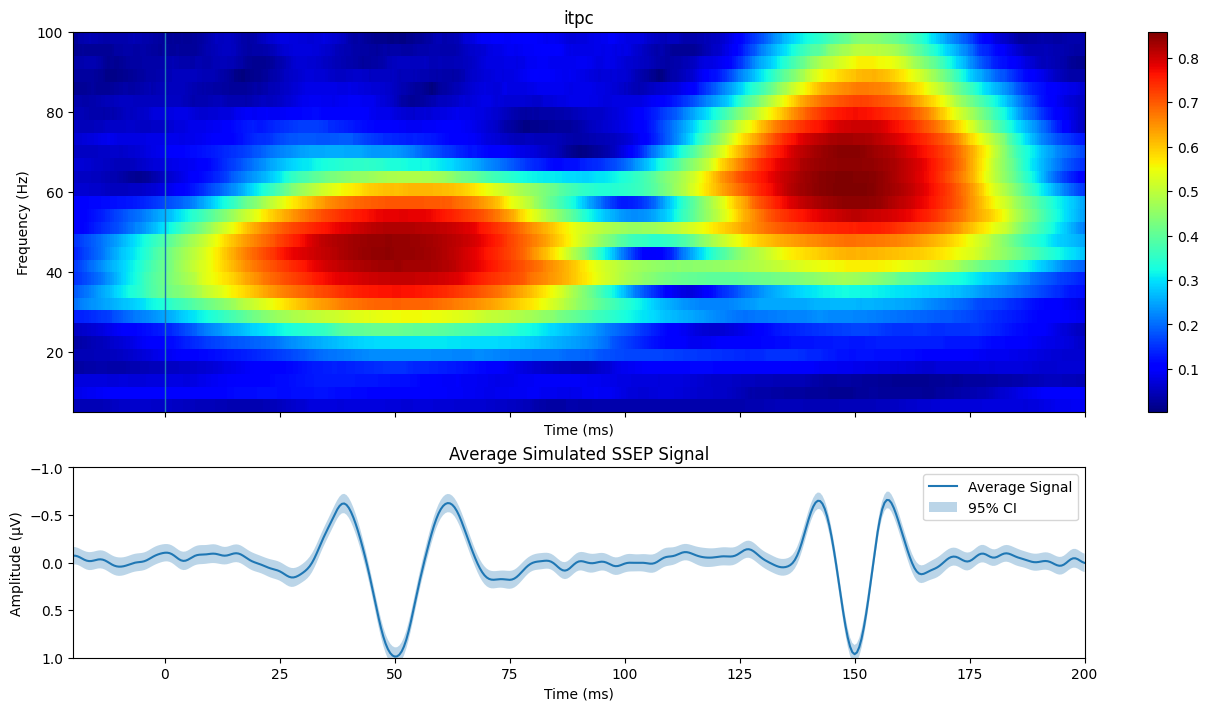

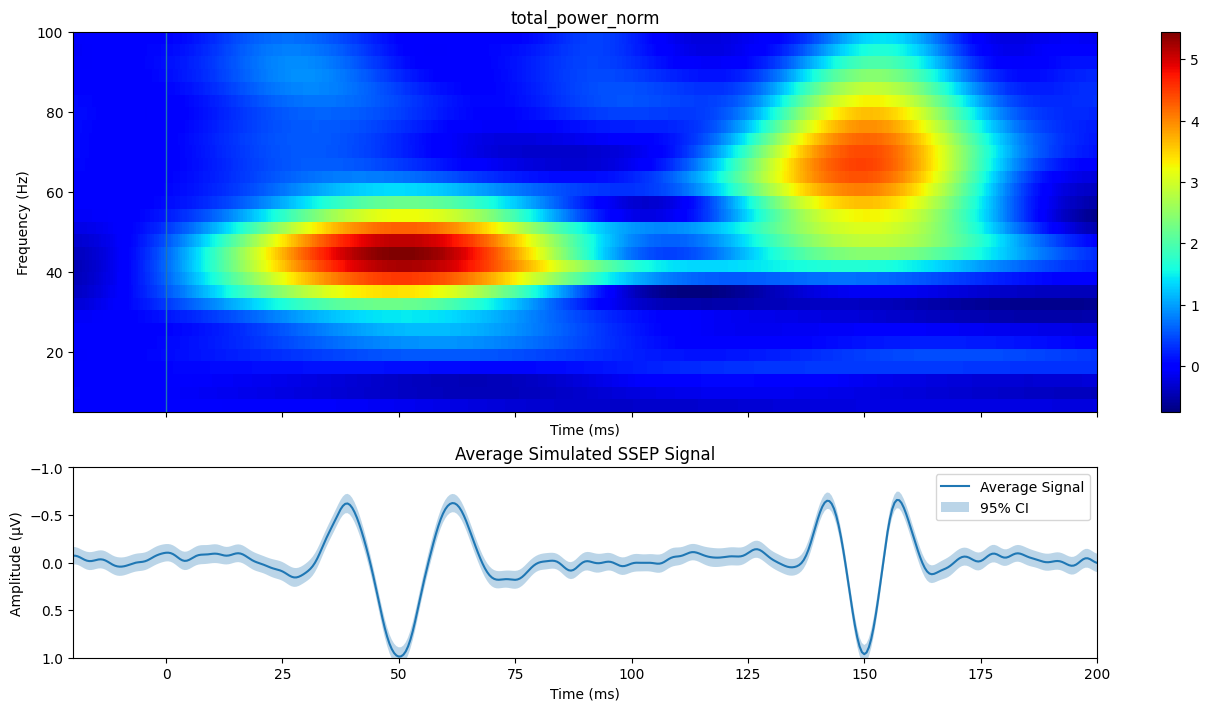

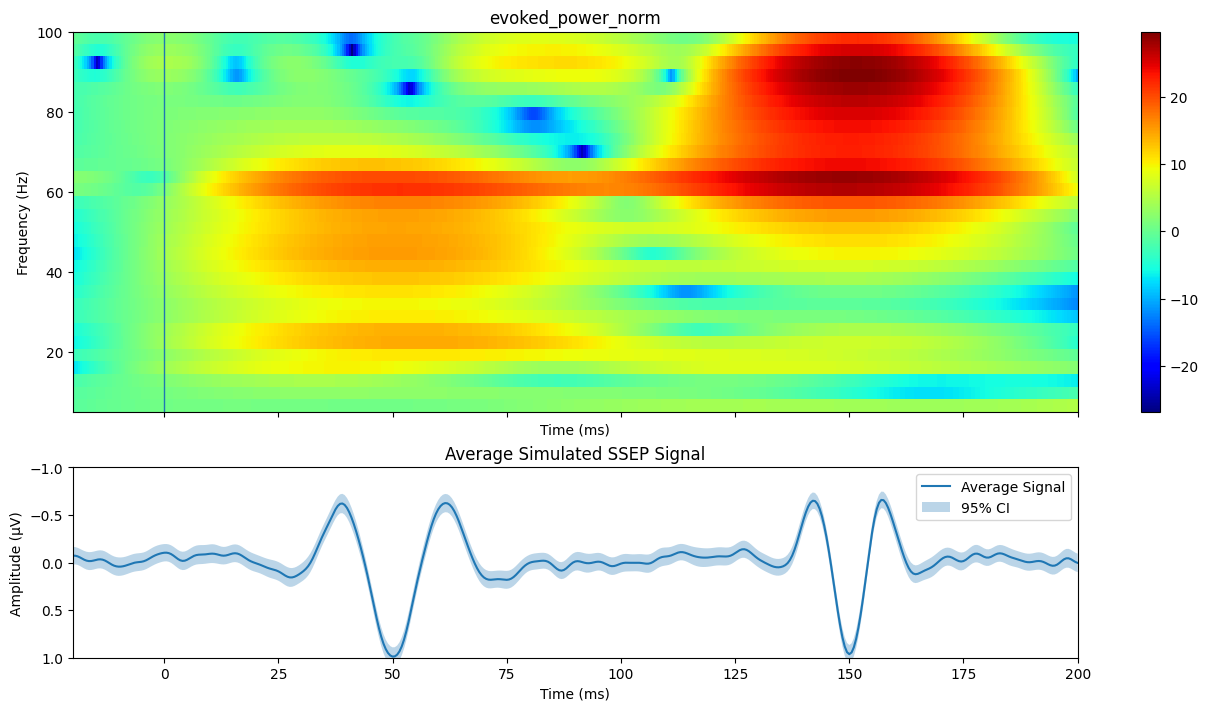

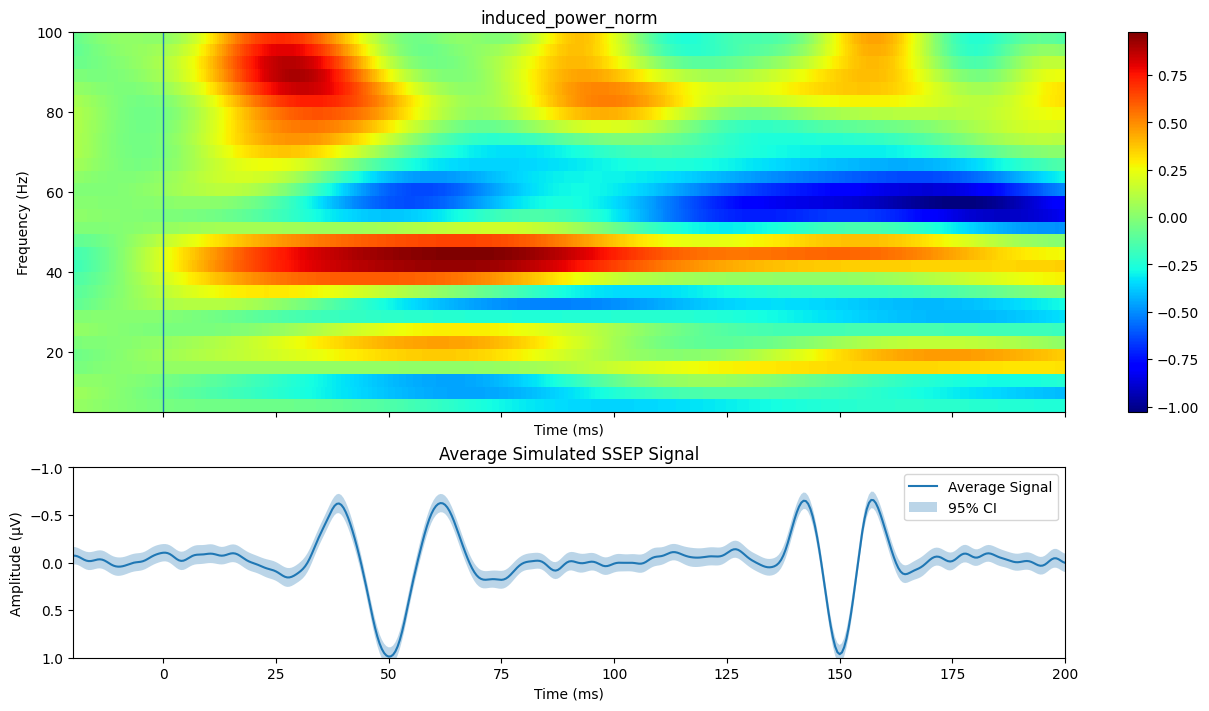

In [76]:
# try on test dataset
# 1) compute complex TF once
dataset.compute_tf_complex_from_wavelet_family(wavefam, store=True,normalize_wavelet_fft=False)

# 2) compute metrics anytime
m = dataset.tf_metrics(baseline_ms=(-20, 0), kind="db", store=True)

m["total_power_norm"]    # (freq, time)
m["induced_power_norm"]
m["evoked_power_norm"]
m["itpc"]


# try the report generation
fig = dataset.plot_report(
    tf_metric="itpc",
    tlim_ms=(-20, 200),
    flim_hz=(5, 250),
    erp_ylim=(-1, 1),
    #tf_clim=(0, 1),
    show=False
)

fig = dataset.plot_report(
    tf_metric="total_power_norm",
    tlim_ms=(-20, 200),
    flim_hz=(5, 250),
    erp_ylim=(-1, 1),
    #tf_clim=(-2, 2),
    show=False
)

fig = dataset.plot_report(
    tf_metric="evoked_power_norm",
    tlim_ms=(-20, 200),
    flim_hz=(5, 250),
    erp_ylim=(-1, 1),
    #tf_clim=(-20, 20),
    show=False
)

fig = dataset.plot_report(
    tf_metric="induced_power_norm",
    tlim_ms=(-20, 200),
    flim_hz=(5, 250),
    erp_ylim=(-1, 1),
    #tf_clim=(-2, 2),
    show=False
)
